In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True

In [2]:
df = pd.read_csv('Ratio2.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (Formula),Mn/Mp (FEM)
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663,0.9604
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.783431,0.8763
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.777522,0.7547
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.825769,0.6167
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.889904,0.4240


In [3]:
df = df.drop(columns=['Mn/Mp (Formula)'])
df = df.rename(columns={'Mn/Mp (FEM)':'Mn/Mp'})
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.9604
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.8763
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.7547
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.6167
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.4240


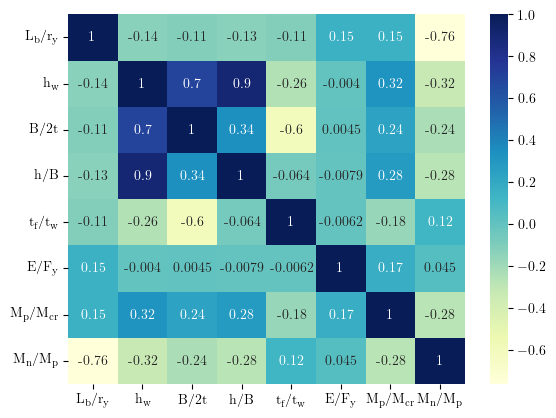

In [4]:
tempdf = df.rename(columns=
    {"Lb/ry": r"L\textsubscript{b}/r\textsubscript{y}",
     "h/tw" :r"h\textsubscript{w}",
     "tf/tw" : r"t\textsubscript{f}/t\textsubscript{w}",
     "E/Fy" : r"E/F\textsubscript{y}",
     "Mp/Mcr" : r"M\textsubscript{p}/M\textsubscript{cr}",
     "Mn/Mp" : r"M\textsubscript{n}/M\textsubscript{p}"
    }, errors="raise")
sns.heatmap(tempdf.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.savefig(f'crosscorrelation.png', dpi=640, bbox_inches='tight')

In [5]:
df_stats = df.describe().transpose()
df_stats = df_stats[['mean', 'std']]
df_stats['variance'] = df_stats['std'] ** 2
df_stats

,mean,std,variance
Lb/ry,97.366596,37.083167,1375.161280
h/tw,34.963695,14.070018,197.965420
B/2t,5.634730,1.363515,1.859172
h/B,1.853852,0.583968,0.341018
tf/tw,1.653545,0.116217,0.013506
E/Fy,248.937214,40.796326,1664.340176
Mp/Mcr,1.624280,0.948242,0.899163
Mn/Mp,0.597387,0.236144,0.055764


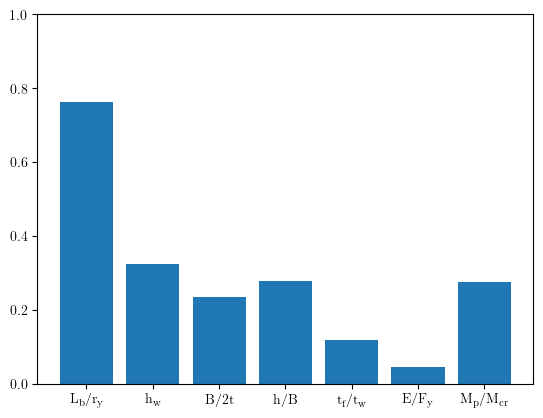

In [6]:
C = tempdf.corr(numeric_only=True)[r'M\textsubscript{n}/M\textsubscript{p}'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

plt.savefig(f'correlation-with-Mn-Mp.png', dpi=640, bbox_inches='tight')

In [7]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)

In [9]:
def evaluate_pipeline(pipeline, threshold=0.2):
    pipeline_train_prd = pipeline.predict(X_train)
    pipeline_train_outliers = np.abs(pipeline_train_prd - y_train) > threshold
    mod_pipeline_train_prd = pipeline_train_prd[~ pipeline_train_outliers]
    mod_y_train = y_train[~ pipeline_train_outliers]
    pipeline_train_mse = mean_squared_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_mae = mean_absolute_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_r2_score = r2_score(mod_pipeline_train_prd, mod_y_train)
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_outliers = np.abs(pipeline_test_prd - y_test) > threshold
    mod_pipeline_test_prd = pipeline_test_prd[~ pipeline_test_outliers]
    mod_y_test = y_test[~ pipeline_test_outliers]
    pipeline_test_mse = mean_squared_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_mae = mean_absolute_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_r2_score = r2_score(mod_pipeline_test_prd, mod_y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_outliers = np.abs(pipeline_full_prd - y_full) > threshold
    mod_pipeline_full_prd = pipeline_full_prd[~ pipeline_full_outliers]
    mod_y_full = y_full[~ pipeline_full_outliers]
    pipeline_full_mse = mean_squared_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_mae = mean_absolute_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_r2_score = r2_score(mod_pipeline_full_prd, mod_y_full)
    
    metrics = {
        'y_train': mod_y_train,
        'y_test' : mod_y_test,
        'train_mse': pipeline_train_mse,
        'train_mae': pipeline_train_mae,
        'train_r2': pipeline_train_r2_score,
        'test_mse': pipeline_test_mse,
        'test_mae': pipeline_test_mae,
        'test_r2': pipeline_test_r2_score,
        'full_mse': pipeline_full_mse,
        'full_mae': pipeline_full_mae,
        'full_r2': pipeline_full_r2_score,
        'train_predictions': mod_pipeline_train_prd,
        'test_predictions': mod_pipeline_test_prd
    }

    return metrics

def plot_accuracy(pipeline_metrics, title):
    print(title)
    print(pipeline_metrics)
    y_train = pipeline_metrics['y_train']
    y_test = pipeline_metrics['y_test']
    
    pipeline_train_prd = pipeline_metrics['train_predictions']
    pipeline_test_prd = pipeline_metrics['test_predictions']
    pipeline_train_r2_score = pipeline_metrics['train_r2']
    pipeline_test_r2_score = pipeline_metrics['test_r2']
    pipeline_full_r2_score = pipeline_metrics['full_r2']
    
    
    fig_train, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_train_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_train.savefig(f'{title}/{title}-train.png', dpi=640, bbox_inches='tight')

    fig_test, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_test_r2_score:.5f}$')
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_test.savefig(f'{title}/{title}-test.png', dpi=640, bbox_inches='tight')

    fig_full, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_full_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_full.savefig(f'{title}/{title}-full.png', dpi=640, bbox_inches='tight')

def plot_cross_validation(cv_result, titlename):
    mean_mse = cv_result['mean_test_score']
    criterions = cv_result['params'][0].keys()
    
    params_df = pd.DataFrame(cv_result['params'].tolist())
    heatmap_data = params_df.copy()
    heatmap_data['mean_r2'] = mean_mse
    if all(mean_mse < 0):
        heatmap_data['mean_r2'] = -mean_mse

    for col in params_df.columns:
        df = heatmap_data.groupby(col)['mean_r2'].min()
        metrics = df.keys().tolist()
        values = df.values.tolist()
        
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()

        values = np.concatenate((values, [values[0]]))  # Close the loop
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        # print(np.max(values) * 1.1)
        # ax.set_rlim(np.max(values) * 1.1)
        ax.margins(0.1)
        ax.scatter(angles, values)
        ax.plot(angles, values, '--')
        ax.fill(angles, values, alpha=0.25)
        
        # Set axis labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)

        plt.savefig(f'{titlename}/{titlename}-hyperparam-{col}.png', dpi=640, bbox_inches='tight')

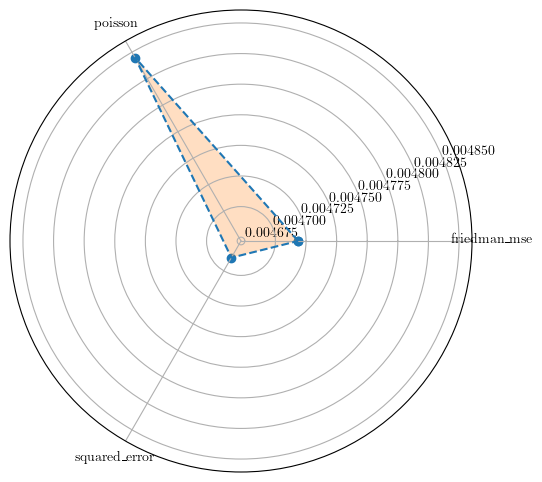

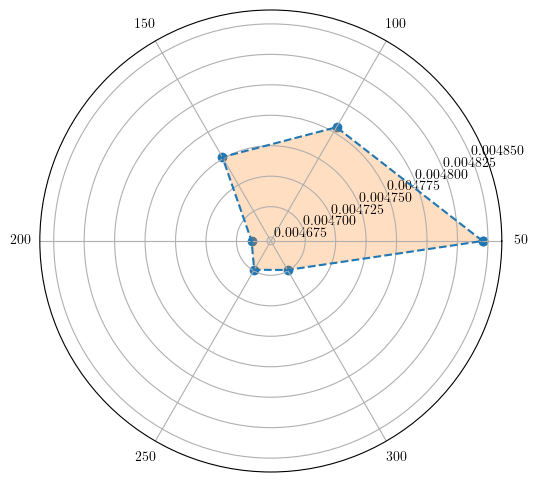

In [10]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
}

rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='neg_mean_squared_error')
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
rf_metrics = evaluate_pipeline(rf_best)

rf_cv_result = pd.DataFrame(rf_cv.cv_results_)
plot_cross_validation(rf_cv_result, 'random-forest')

random-forest
{'y_train': 21     0.7025
430    0.2226
79     0.7553
408    0.7446
313    0.8919
        ...  
230    0.6186
98     0.7948
322    0.8983
382    0.6551
365    0.5576
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.3053
125    0.7839
287    0.3859
204    0.6789
172    0.7688
        ...  
199    0.3580
31     0.3579
240    0.8102
59     0.3050
328    0.3584
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.0005995115804318249, 'train_mae': 0.01790071306818194, 'train_r2': 0.9883719825608568, 'test_mse': 0.0036137032304747172, 'test_mae': 0.044784028089887656, 'test_r2': 0.9291871098234986, 'full_mse': 0.0012078178318010251, 'full_mae': 0.023326143990929804, 'full_r2': 0.9765676536952007, 'train_predictions': array([0.7012475, 0.21818  , 0.7626085, 0.7343665, 0.8382675, 0.7140535,
       0.409499 , 0.769398 , 0.3852195, 0.2912375, 0.836553 , 0.326813 ,
       1.0243655, 0.8656925, 0.6598455, 0.963223 , 0.331741 , 0.6811435,
       0.283934 , 0.8409055, 0.

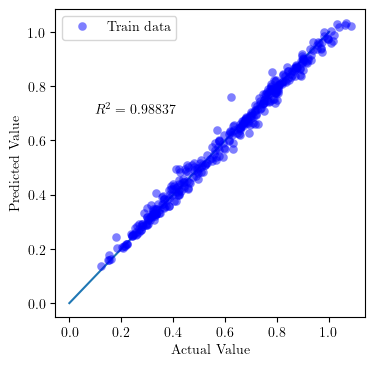

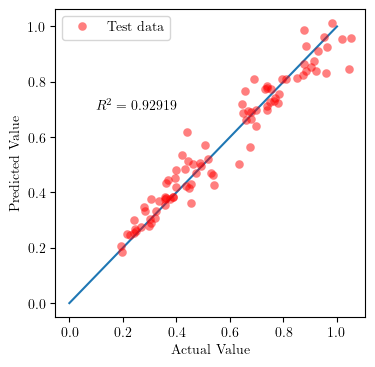

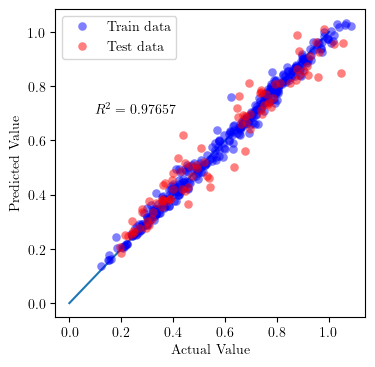

In [11]:
rf_metrics = evaluate_pipeline(rf_best)
plot_accuracy(rf_metrics, 'random-forest')

In [35]:
gb_params = {
    'n_estimators' : [100, 200, 300, 400, 500],
    'learning_rate' : [0.01, 0.02, 0.05, 0.1, 0.2],
    'max_depth' : [2, 3, 4, 5],
}

gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42, subsample=0.7), gb_params, scoring='neg_mean_squared_error')
gb_cv.fit(X_train, y_train)
gb_best = gb_cv.best_estimator_

print(gb_cv.best_params_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}


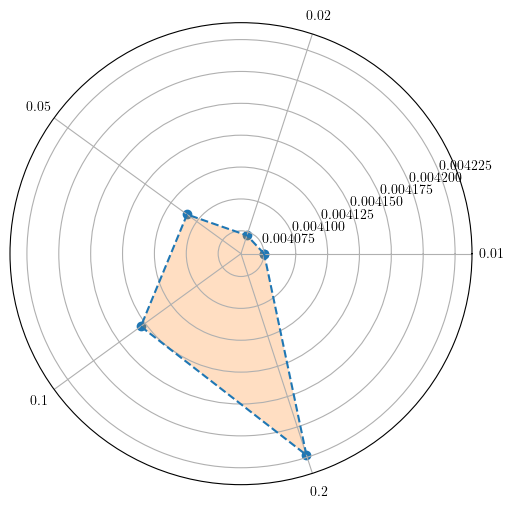

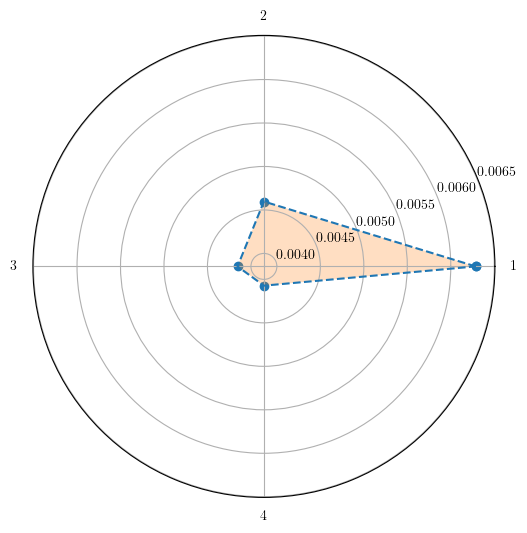

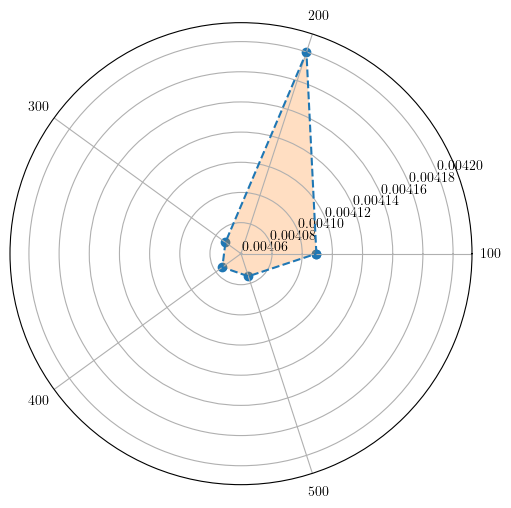

In [34]:
gb_cv_result = pd.DataFrame(gb_cv.cv_results_)
plot_cross_validation(gb_cv_result, 'gradient-boosting')

gradient-boosting
{'y_train': 21     0.7025
430    0.2226
79     0.7553
408    0.7446
313    0.8919
        ...  
230    0.6186
98     0.7948
322    0.8983
382    0.6551
365    0.5576
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.3053
125    0.7839
287    0.3859
204    0.6789
172    0.7688
        ...  
199    0.3580
31     0.3579
240    0.8102
59     0.3050
328    0.3584
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.0008573833835393702, 'train_mae': 0.023139381935654527, 'train_r2': 0.9832946546505842, 'test_mse': 0.0036468349297029434, 'test_mae': 0.04481023113527697, 'test_r2': 0.9285901158253413, 'full_mse': 0.0014203339223342862, 'full_mae': 0.027512863973673574, 'full_r2': 0.9723772802556019, 'train_predictions': array([0.71469004, 0.23437301, 0.76295282, 0.74271925, 0.85420176,
       0.70491323, 0.39681353, 0.76736363, 0.38744995, 0.29828345,
       0.83795824, 0.3209905 , 1.02722313, 0.85014085, 0.68124196,
       0.98827126, 0.32742658, 0.66532148, 0.

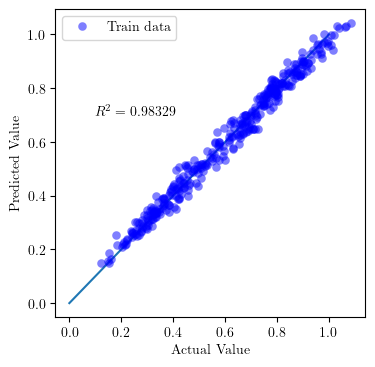

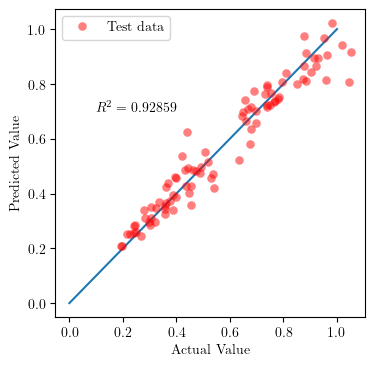

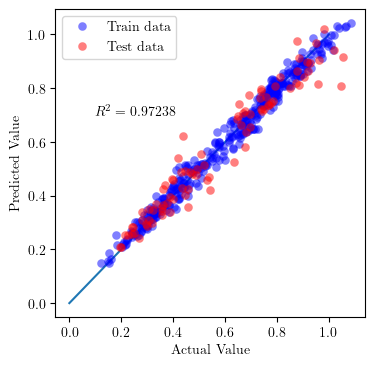

In [14]:
gb_metrics = evaluate_pipeline(gb_best, 1000000000)
plot_accuracy(gb_metrics, 'gradient-boosting')

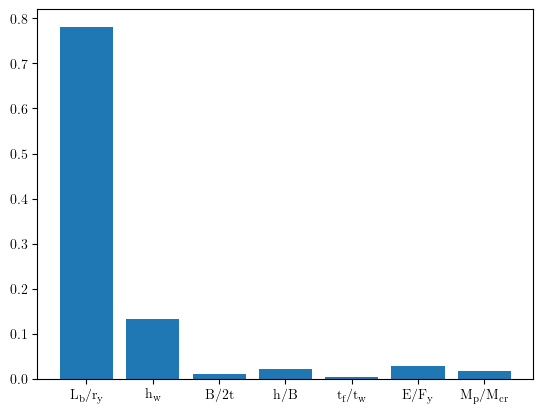

In [15]:
feature_importance = gb_best.feature_importances_
plt.bar(tempdf.columns[:7], feature_importance)
plt.savefig('gradient-boosting/feature-imp.png', dpi=640, bbox_inches='tight')

In [16]:
from sklearn.svm import LinearSVR, SVR
from scipy.stats import loguniform, uniform
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'rbf', 'poly']
svr_params = {
    'svr__C': loguniform(1e-1, 1e2),
    'svr__epsilon': uniform(0.01, 0.1)
}

svr_metrics = dict()

for kernel in ['linear', 'rbf', 'poly']:
    if kernel == 'linear':
        base_model = SVR(kernel=kernel)
        base_params = svr_params
    else:
        base_model = SVR(kernel=kernel)
        base_params = {**svr_params, 'svr__gamma': loguniform(1e-3, 1e3)}

    svr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', base_model)
    ])

    svr_cv = RandomizedSearchCV(svr_pipeline, base_params, n_iter=10, random_state=100, n_jobs=-1, scoring='neg_mean_squared_error')
    svr_cv.fit(X_train, y_train)
    
    svr_best = svr_cv.best_estimator_
    svr_cv_result = pd.DataFrame(svr_cv.cv_results_)
    print(svr_cv.best_params_)

    svr_metrics[kernel] = evaluate_pipeline(svr_best)

{'svr__C': np.float64(1.8773825301295222), 'svr__epsilon': np.float64(0.09447761323199037)}
{'svr__C': np.float64(34.2238132147075), 'svr__epsilon': np.float64(0.010471885619097256), 'svr__gamma': np.float64(0.005363085549653507)}
{'svr__C': np.float64(4.2679058013626765), 'svr__epsilon': np.float64(0.037836938509379615), 'svr__gamma': np.float64(0.3524565164435525)}


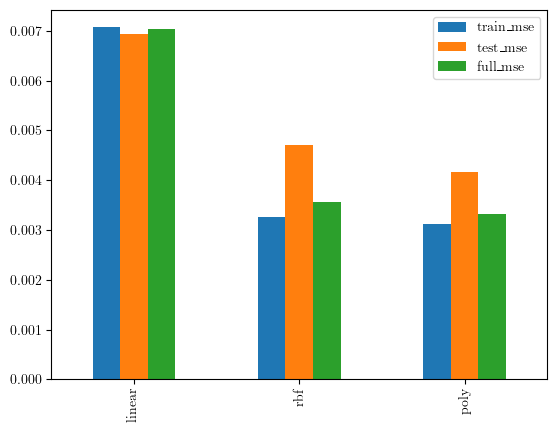

In [17]:
pd.DataFrame(svr_metrics).filter(regex='_mse', axis=0).transpose().plot.bar()
plt.savefig('svr/svr-kernel-mse.png', dpi=640, bbox_inches='tight')

SVR-linear
{'y_train': 21     0.7025
430    0.2226
79     0.7553
408    0.7446
313    0.8919
        ...  
230    0.6186
98     0.7948
322    0.8983
382    0.6551
365    0.5576
Name: Mn/Mp, Length: 337, dtype: float64, 'y_test': 13     0.3053
125    0.7839
287    0.3859
204    0.6789
172    0.7688
        ...  
199    0.3580
31     0.3579
240    0.8102
59     0.3050
328    0.3584
Name: Mn/Mp, Length: 87, dtype: float64, 'train_mse': 0.0070673826430719495, 'train_mae': 0.07160472332760653, 'train_r2': 0.8262331497937443, 'test_mse': 0.006925154351980992, 'test_mae': 0.06839708177728729, 'test_r2': 0.8492330660660239, 'full_mse': 0.007038199007871682, 'full_mae': 0.07094655159440423, 'full_r2': 0.8318347966224917, 'train_predictions': array([0.67557953, 0.18904911, 0.65392924, 0.6629475 , 0.95752902,
       0.64147955, 0.4510221 , 0.66376754, 0.49985274, 0.36252547,
       0.75936216, 0.41091387, 0.96323097, 0.79321808, 0.6471575 ,
       0.97582396, 0.33431621, 0.5817823 , 0.40199984, 0

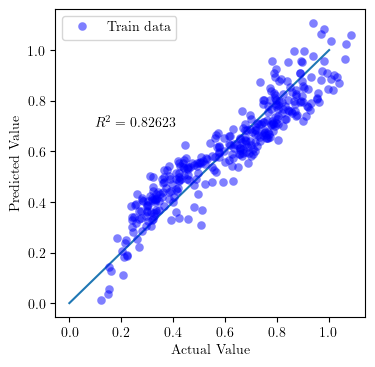

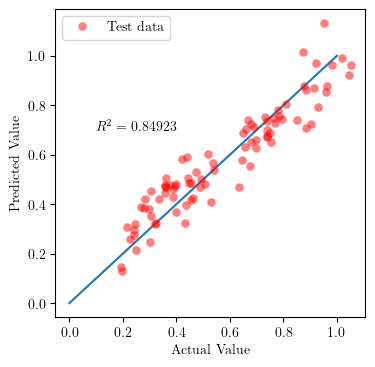

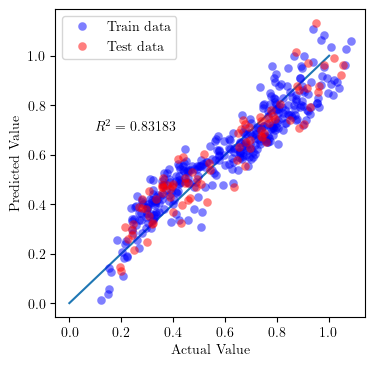

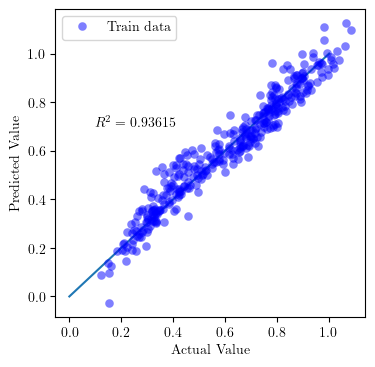

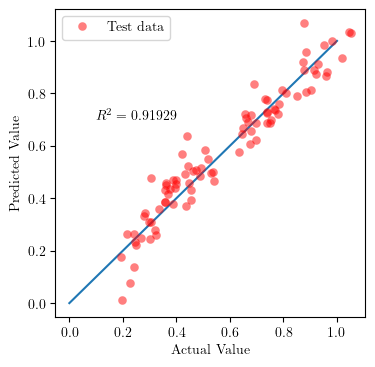

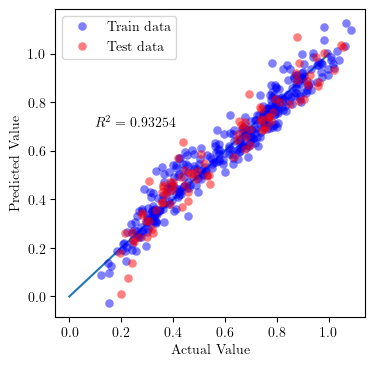

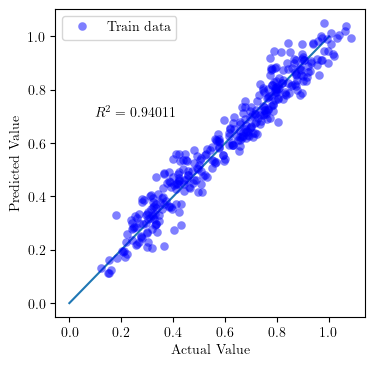

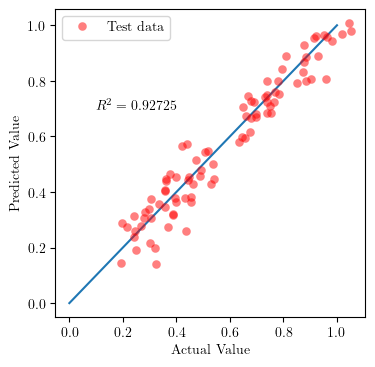

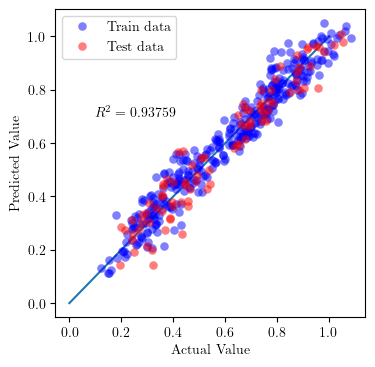

In [18]:
for kernel in kernels:
    plot_accuracy(svr_metrics[kernel], f'SVR-{kernel}')

In [19]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(20, 20, 20, 20, 20, 20, 20)],
    'mlp__activation' : ['relu'],
    'mlp__solver': ['lbfgs']
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=1000))
])

nn_cv = GridSearchCV(nn_pipeline, nn_params, scoring='neg_mean_squared_error')
nn_cv.fit(X_train, y_train)

nn_best = nn_cv.best_estimator_
nn_cv_result = pd.DataFrame(nn_cv.cv_results_)

# plt.subplot(2, 1, 1)
# plt.semilogy(nn_best['mlp'].loss_curve_)
# plt.subplot(2, 1, 2)
# plt.plot(nn_best['mlp'].validation_scores_)
# plt.savefig('MLP/mlp.png', dpi=640, bbox_inches='tight')

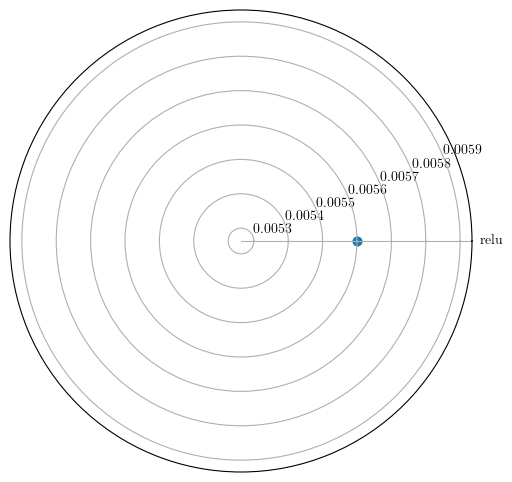

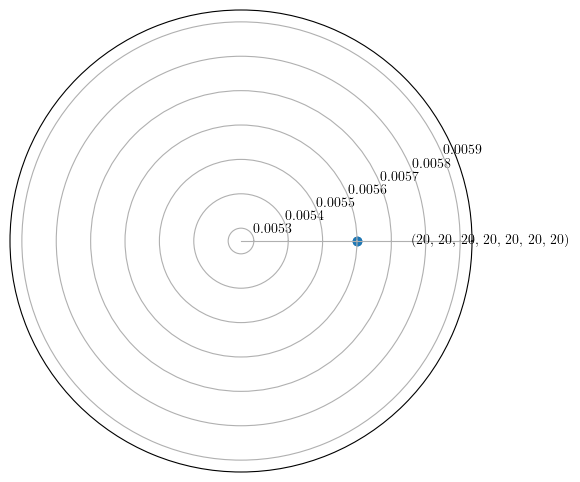

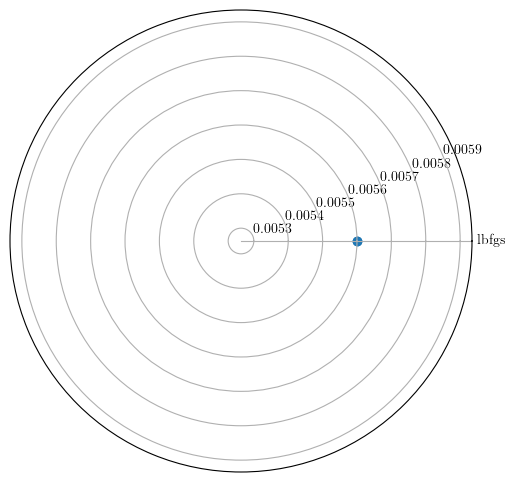

In [20]:
plot_cross_validation(nn_cv_result, 'mlp-hyperparams')

MLP
{'y_train': 21     0.7025
430    0.2226
79     0.7553
408    0.7446
313    0.8919
        ...  
230    0.6186
98     0.7948
322    0.8983
382    0.6551
365    0.5576
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.3053
125    0.7839
287    0.3859
204    0.6789
172    0.7688
        ...  
199    0.3580
31     0.3579
240    0.8102
59     0.3050
328    0.3584
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.00015793736702850918, 'train_mae': 0.008877663172757606, 'train_r2': 0.9971016759585619, 'test_mse': 0.0031070028954831813, 'test_mae': 0.04298036192877849, 'test_r2': 0.946799107924571, 'full_mse': 0.0007531002514558694, 'full_mae': 0.015760067230095157, 'full_r2': 0.9863907638402675, 'train_predictions': array([0.69985767, 0.22135991, 0.7375189 , 0.72012171, 0.89576753,
       0.72470453, 0.40564054, 0.77384117, 0.35126283, 0.28232491,
       0.87192145, 0.32801581, 1.0487813 , 0.88447679, 0.64307202,
       0.95236169, 0.33315329, 0.67899265, 0.27338267, 0.81

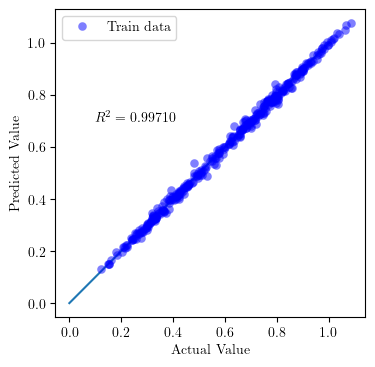

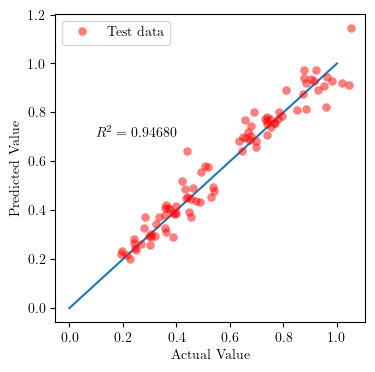

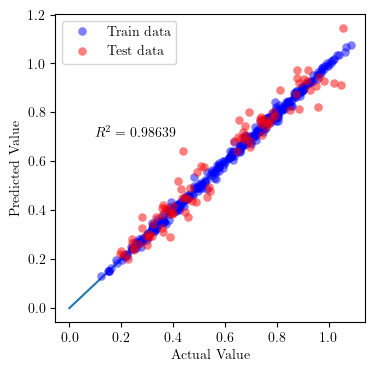

In [21]:
nn_metrics = evaluate_pipeline(nn_best, 0.3)
plot_accuracy(nn_metrics, 'MLP')

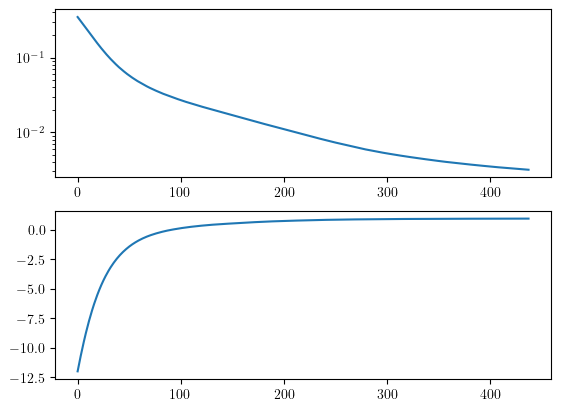

In [22]:
small_nn_params = {
    'mlp__hidden_layer_sizes' : [(x,) for x in range(1, 15)],
    'mlp__activation' : ['relu', 'tanh', 'logistic']
}

small_nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=2000))
])

small_nn_cv = GridSearchCV(small_nn_pipeline, small_nn_params, scoring='neg_mean_squared_error')
small_nn_cv.fit(X_train, y_train)

small_nn_best = small_nn_cv.best_estimator_
small_nn_cv_result = pd.DataFrame(small_nn_cv.cv_results_)

plt.subplot(2, 1, 1)
plt.semilogy(small_nn_best['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(small_nn_best['mlp'].validation_scores_)
plt.savefig('small-nn/small-nn.png', dpi=640, bbox_inches='tight')

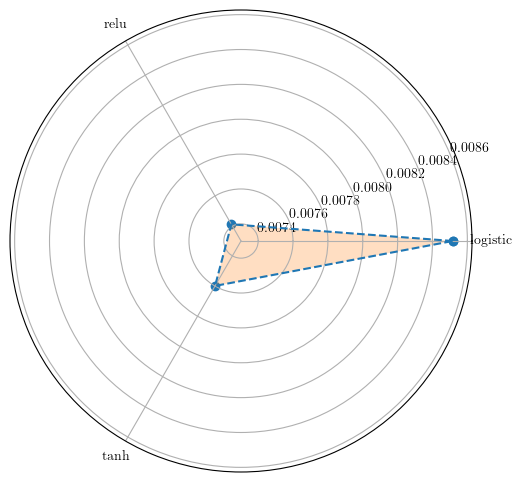

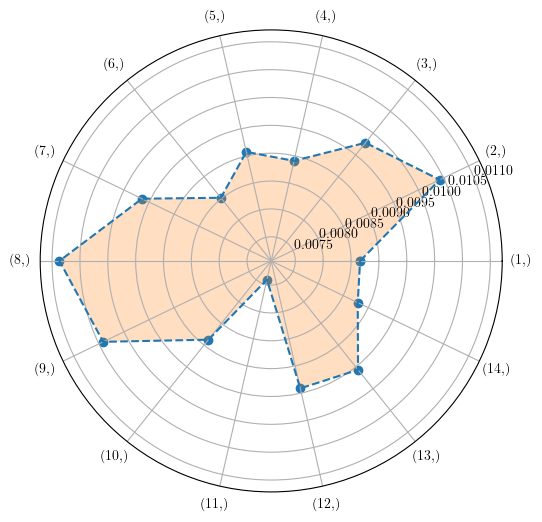

In [23]:
plot_cross_validation(small_nn_cv_result, 'small-nn-hyperparameters')

small-nn
{'y_train': 21     0.7025
430    0.2226
79     0.7553
408    0.7446
313    0.8919
        ...  
230    0.6186
98     0.7948
322    0.8983
382    0.6551
365    0.5576
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.3053
125    0.7839
287    0.3859
204    0.6789
172    0.7688
        ...  
199    0.3580
31     0.3579
240    0.8102
59     0.3050
328    0.3584
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.006071040589804233, 'train_mae': 0.06136529929455341, 'train_r2': 0.8750957508153462, 'test_mse': 0.004807694373340555, 'test_mae': 0.05362281104874631, 'test_r2': 0.9085376249503303, 'full_mse': 0.005816079561991835, 'full_mae': 0.059802756315240874, 'full_r2': 0.8825276218482884, 'train_predictions': array([ 0.68398459,  0.33217558,  0.70026407,  0.75471432,  0.85938613,
        0.68930614,  0.42320401,  0.68428864,  0.4669929 ,  0.35834948,
        0.76387266,  0.3520154 ,  1.08063514,  0.79053159,  0.52314594,
        0.93062402,  0.30364194,  0.6669653

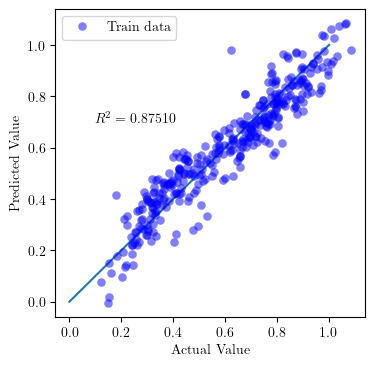

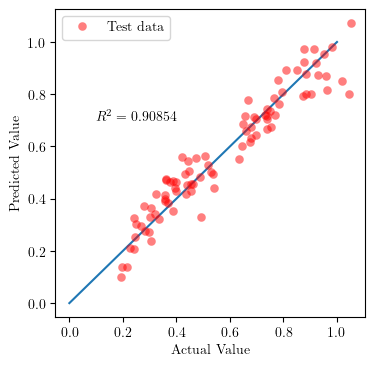

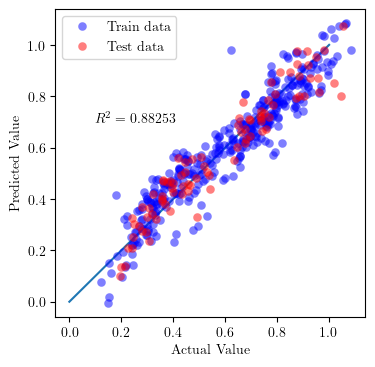

In [24]:
small_nn_metrics = evaluate_pipeline(small_nn_best, 100.0)
plot_accuracy(small_nn_metrics, 'small-nn')

In [25]:
og_data = pd.read_csv('original.csv')
og_data.head()

,Fy (ksi),Lb,bf,tf,tw,h0,ry,Mn(Modified),Mn(AISC code),Mn(FE model),Mp,b,Mcr
0,139.236,160,15.9,1.77,1.03,42.23,3.49,190298.5274,225562.320000,216638.377325,225562.32,15.9,399132.605082
1,139.236,190,15.9,1.77,1.03,42.23,3.49,171595.1703,219030.340139,197650.133747,225562.32,15.9,290051.468297
2,139.236,230,15.9,1.77,1.03,42.23,3.49,146147.7541,187966.043520,170240.744021,225562.32,15.9,205359.253150
3,139.236,260,15.9,1.77,1.03,42.23,3.49,128748.2021,155913.110942,139104.281134,225562.32,15.9,165618.043830
4,139.236,300,15.9,1.77,1.03,42.23,3.49,108993.2842,122477.537470,95629.312666,225562.32,15.9,129821.641396


In [26]:
og_data_ratio = pd.DataFrame()
og_data_ratio['Lb/ry'] = og_data['Lb'] / og_data['ry']
og_data_ratio['h/tw'] = og_data['h0'] / og_data['tw']
og_data_ratio['B/2t'] = og_data['b'] / 2 * og_data['tf']
og_data_ratio['h/B'] = og_data['h0'] / og_data['b']
og_data_ratio['tf/tw'] = og_data['tf'] / og_data['tw']
og_data_ratio['E/Fy'] = 29e3 / og_data['Fy (ksi)']
og_data_ratio['Mp/Mcr'] = og_data['Mp'] / og_data['Mcr']
og_data_ratio['Mn/Mp (AISC)'] = og_data['Mn(AISC code)'] / og_data['Mp']
og_data_ratio['Mn/Mp (MOD)'] = og_data['Mn(Modified)'] / og_data['Mp']

In [27]:
og_data_ratio.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (AISC),Mn/Mp (MOD)
0,45.845272,41.0,14.0715,2.655975,1.718447,208.279468,0.565131,1.000000,0.843663
1,54.441261,41.0,14.0715,2.655975,1.718447,208.279468,0.777663,0.971041,0.760744
2,65.902579,41.0,14.0715,2.655975,1.718447,208.279468,1.098379,0.833322,0.647926
3,74.498567,41.0,14.0715,2.655975,1.718447,208.279468,1.361943,0.691220,0.570788
4,85.959885,41.0,14.0715,2.655975,1.718447,208.279468,1.737479,0.542988,0.483207


In [28]:
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.9604
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.8763
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.7547
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.6167
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.4240


In [29]:
mse_code = mean_squared_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
r2_code = r2_score(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mse_code)
print(r2_code)

0.027484151024631094
0.6181763301765262


In [30]:
mae_code = mean_absolute_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mae_code)

0.12830643132026942
